In [ ]:
from Agent.AbstractLearner import AbstractLearner
from Agent.AbstractLearner import AbstractLearner
from Agent.neural_nets.MLP import MLP
from Agent.dyn_utils.utils import euler_integration
import torch 




class PINNLearner(AbstractLearner):

    def __init__(self, params, demos):
        
        super().__init__()

        self.batch_size = params.batch_size
        self.device = params.device

        self.demos = demos.to(self.device) # in the form of [idx, horizon, (x, u, t)]
        self.n_demos = len(demos)
        self.state_dim = params.state_dim
        self.action_dim = params.input_dim
        self.horizon = params.horizon


        self.model = MLP(
            state_dim=params.state_dim,
            input_dim=params.input_dim,
            n_hidden_layer=params.n_hidden_layer,
            latent_dim=params.latent_dim, 
            time=True
        ).to(self.device)

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=params.lr,
            weight_decay=params.weight_decay
            )

        # loss computing stuff
        # --------------------

        self.jac_funct = torch.func.jacrev(self.model)
        self.mse = torch.nn.MSELoss()
        

    def propagate(self, input_tensor):
        # no euler integration in this learner 
        x_next = self.model(input_tensor)
        return x_next

    def calc_loss(self, x):

        self.imit_weight = 1.0
        loss_imit = self.imit_weight * self.imit_loss(x)
        
        self.physic_weight = 1.0
        loss_physic = self.physic_weight * self.physic_loss()

        # self.boundary_weight = 0.8 
        # loss_boundary = self.boundary_weight * self.boundary_loss()

        # return loss_imit + loss_physic + loss_boundary
        return loss_imit + loss_physic

    def boundary_loss(self):

        # zero velocity = no motion 
        sampled_zero_input = torch.randn(32, 6)
        sampled_zero_input[:, self.state_dim:-1] = 0
        sampled_zero_input.requires_grad = True
        sampled_zero_input = sampled_zero_input.to(self.device)

        jac = torch.vmap(self.jac_funct)(sampled_zero_input)
        dx_dt = jac[:, :, -1]
        ode_model = torch.zeros_like(dx_dt)

        cost = torch.mean((ode_model - dx_dt)**2)
        return cost
        
    def physic_loss(self):

        self.delta_t = 0.3

        sampled_points = torch.randn(32, 6)
        sampled_points.requires_grad = True
        sampled_points = sampled_points.to(self.device)

        jac = torch.vmap(self.jac_funct)(sampled_points)
        x_next = self.model(sampled_points) 
        x_t = sampled_points[:, :self.state_dim] 
        time_der = (x_next - x_t) / self.delta_t

        jac = torch.sum(jac, dim=-1)
        f_dot = jac * time_der 

        state_sampled = sampled_points[:, :self.state_dim]
        action_sampled = sampled_points[:, self.state_dim:-1]

        # forward pass of kin models
        ode_model = torch.empty(32, 3).to(self.device)
        ode_model[:, 0] = torch.cos(state_sampled[:, -1]) * action_sampled[:, 0]
        ode_model[:, 1] = torch.sin(state_sampled[:, -1]) * action_sampled[:, 0]
        ode_model[:, 2] = action_sampled[:, 1]
        
        cost = torch.mean((ode_model - f_dot)**2)

        return cost 


    def imit_loss(self, x):

        states = x[:, :, :self.state_dim]   # [batch, horizon, 3]
        actions = x[:, :, self.state_dim:-1]  # [batch, horizon, 2]
        t = x[:, :, -1].unsqueeze(-1)  # [batch, horizon]

        next_pair = [torch.hstack((
            states[:, 0, :],
            actions[:, 0, :],
            t[:, 0, :]
            ))]

        next_states = [states[:, 0, :].unsqueeze(-1)]
                
        for k in range(self.horizon-1):

            x_t_next = self.propagate(next_pair[-1])

            next_states.append(x_t_next.unsqueeze(-1))
            next_pair.append(torch.hstack((
                x_t_next,
                actions[:, k+1, :],
                t[:, k+1, :]
            )))

        generated_traj = torch.concatenate(next_states, dim=-1)
        generated_traj = generated_traj.permute(0, 2, 1)

        loss = self.mse(states, generated_traj)
        return loss

    def sample_data(self):
        
        return self.demos[
            torch.randint(
                low=0,
                high=self.n_demos,
                size=(self.batch_size,)
            )
        ]

    def simulate_trajectory(self, raw_trajectory):
        
        raw_trajectory = torch.FloatTensor(raw_trajectory).to(self.device)
        x = raw_trajectory[0, :self.state_dim]
        states = [x]

        # the net require input of shape (batch=1, state_dim + input_dim)
        # add the batch dim 
        x = x.unsqueeze(0)

        for i in range(len(raw_trajectory) - 1):

            # create the input tensor as concatenation of state and action
            input_tensor = torch.hstack(
                (x, raw_trajectory[i, self.state_dim:].unsqueeze(0))
            )
            x = self.propagate(
                input_tensor
                )
            states.append(x.squeeze(0))

        return torch.stack(states, dim=0)





In [1]:
import torch
import deepxde as dde
import numpy as np

import os
os.getcwd()

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


'/home/dema/Project/flavie'

In [94]:
path = 'neural_model_identification/data_module/trajectories/sample_0'
traj = np.load(path + '/states.npy')
actions = np.load(path + '/actions.npy')

delta_t = 0.3
T = 0
time_traj = np.arange(0, len(traj)*delta_t, delta_t)

time_traj.max()

300.3

In [2]:
import torch.nn as nn 

class NET(nn.Module):


    def __init__(self):
        super(NET, self).__init__()
        self.mlp = torch.nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.mlp(x)


In [37]:
def uniKin(x):
    print('x_shape oriignial : ' , x.shape)
    x, u = x[:, :3], x[:, 3:]
    print('x shape  ', x.shape)

    print('u shape  ', u.shape)

    x_dot = u[:, 0]*np.cos(x[:, 2])
    y_dot = u[:, 0]*np.sin(x[:, 2])
    theta_dot = u[:, 1]
    return np.hstack((x_dot, y_dot, theta_dot))

In [4]:
x = np.random.randn(1, 3)
y = np.random.randn(1, 2)
uniKin(np.hstack((x, y)))

x_shape oriignial :  (1, 5)
x shape   (1, 3)
u shape   (1, 2)


array([ 1.0442328 ,  0.40079923, -3.05358773])

In [6]:
cube_dim = np.ones((4, 2))
cube_dim[:, 0] *= -1

In [7]:

geom = dde.geometry.Hypercube(cube_dim[:, 0], cube_dim[:, 1])
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [8]:
mlp_ref = NET()


In [9]:
t = torch.randn(1)
mlp_ref(t)

tensor([-0.0515,  0.7219], grad_fn=<AddBackward0>)

In [140]:
import deepxde as dde
import numpy as np

# Time step
dt = time_traj.max()

# The ODE system:
# dx/dt = v cos(theta)
# dy/dt = v sin(theta)
# dtheta/dt = omega

# We will treat (v, omega) as known parameters. 
# One way to handle this in DeepXDE is to include them as inputs alongside t.
# So the network input is (t, v, omega, x0, y0, theta0) and output is (x(t), y(t), theta(t)).
# For a fixed MPC step, we often know (x0, y0, theta0, v, omega). 
# We solve over t in [0, dt], with initial conditions at t=0.

# Geometry and time domain
cube_dim = np.ones((5, 2))*1000
cube_dim[:, 0] *= -1

geom = dde.geometry.Hypercube(cube_dim[:, 0], cube_dim[:, 1])
timedomain = dde.geometry.TimeDomain(0, 1)
time_domain = dde.geometry.GeometryXTime(geom, timedomain)

# We can treat x0, y0, theta0, v, omega as parameters that will be provided as input data points.
# DeepXDE can handle parametric PDEs/ODEs. We will create a parametric PDE problem by extending 
# the input dimension. For simplicity, let's fix (v, omega, x0, y0, theta0) for one training run.
# In practice, you'd sample multiple initial conditions and controls to train a more general network.

# ODE Residuals
def ode_system(x, y):
    # x: input [t, v, omega, x0, y0, theta0] (we will pack them into x)
    # y: output [x(t), y(t), theta(t)]
    # Extract inputs
    t = x[:, 0:1]
    v = x[:, 1:2]
    omega = x[:, 2:3]
    x0 = x[:, 3:4]
    y0 = x[:, 4:5]
    theta0 = x[:, 5:6]

    # Outputs from the network
    x_t = y[:, 0:1]
    y_t_ = y[:, 1:2]
    theta_t = y[:, 2:3]

    # Compute derivatives
    dx_dt = dde.grad.jacobian(y, x, i=0, j=0)   # dy/dt for x(t)
    dy_dt = dde.grad.jacobian(y, x, i=1, j=0)   # dy/dt for y(t)
    dtheta_dt = dde.grad.jacobian(y, x, i=2, j=0) # dy/dt for theta(t)

    # ODE residuals:
    # dx/dt - v cos(theta) = 0
    # dy/dt - v sin(theta) = 0
    # dtheta/dt - omega = 0
    # Note: The output is the full solution y(t), so we can plug in the correct relationship.
    res_x = dx_dt - v * torch.cos(theta_t)
    res_y = dy_dt - v * torch.sin(theta_t)
    res_theta = dtheta_dt - omega

    return [res_x, res_y, res_theta]


# Initial conditions at t=0:
# x(0) = x0, y(0) = y0, theta(0) = theta0
def boundary_left(x, on_initial):
    return on_initial

# We will specify that y(t=0) = [x0, y0, theta0].
# But x0, y0, theta0 are given as part of input x, so we need a custom IC function.
class ParamIC(dde.icbc.IC):
    def __init__(self, geom, param_index, component):
        # param_index: which input dimension contains the parameter for the initial condition.
        # component: which output component we set the IC for.
        super().__init__(geom, lambda x: 0.0, boundary_left, component=component)
        self.param_index = param_index

    def inside(self, x):
        return boundary_left(x, True)

    def value(self, x):
        # The initial condition for component is just the parameter at param_index
        return x[:, self.param_index:param_index+1]

# We know the mapping of input:
# x[:,0] = t, x[:,1] = v, x[:,2] = omega, x[:,3] = x0, x[:,4] = y0, x[:,5] = theta0
# For initial conditions:
# x(t=0) should be y(t=0) = [x0, y0, theta0]
ic_x = ParamIC(time_domain, param_index=3, component=0)
ic_y = ParamIC(time_domain, param_index=4, component=1)
ic_theta = ParamIC(time_domain, param_index=5, component=2)

# Define the PDE/ODE problem
data = dde.data.PDE(
    geometry=time_domain,
    pde=ode_system,
    bcs=[],
    num_domain=10,
    num_boundary=1,
    # Here we might also add collocation points for different parameters (v, omega, x0, y0, theta0)
    # In a full implementation, you'd either:
    #   1) Sample various v,omega,x0,y0,theta0 sets and treat them as training "parameters"
    #   2) Or fix them and only solve one instance.
)

# Neural network
net = dde.maps.FNN([6] + [64, 64, 64, 3], "tanh", 'Glorot uniform')

# Model
model = dde.Model(data, net)

# Compile and Train
model.compile("adam", lr=1e-3)
model.train(epochs=20000)

Compiling model...
'compile' took 0.000110 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [2.06e+05, 7.70e+04, 3.80e+05]    [2.06e+05, 7.70e+04, 3.80e+05]    []  
1000      [1.36e+05, 1.47e+05, 3.80e+05]    [1.36e+05, 1.47e+05, 3.80e+05]    []  
2000      [1.47e+05, 1.36e+05, 3.80e+05]    [1.47e+05, 1.36e+05, 3.80e+05]    []  
3000      [6.01e+04, 2.23e+05, 3.80e+05]    [6.01e+04, 2.23e+05, 3.80e+05]    []  
4000      [1.51e+05, 1.32e+05, 3.80e+05]    [1.51e+05, 1.32e+05, 3.80e+05]    []  
5000      [1.32e+05, 1.50e+05, 3.80e+05]    [1.32e+05, 1.50e+05, 3.80e+05]    []  
6000      [1.41e+05, 1.42e+05, 3.80e+05]    [1.41e+05, 1.42e+05, 3.80e+05]    []  
7000      [1.42e+05, 1.40e+05, 3.80e+05]    [1.42e+05, 1.40e+05, 3.80e+05]    []  
8000      [6.22e+04, 2.21e+05, 3.80e+05]    [6.22e+04, 2.21e+05, 3.80e+05]    []  
9000      [1.96e+05, 8.70e+04, 3.80e+05]    [1.96e+05, 8.70e+04, 3.80e+05]    []  
10000     [2.07

(<deepxde.model.LossHistory at 0x7fb22b9df5b0>,
 <deepxde.model.TrainState at 0x7fb2cc17c730>)

In [141]:
gen_x = []
for i in range(len(X)):
    gen_x.append(net(X[i]))
    

In [142]:
gen_traj_np = torch.vstack(gen_x).detach().cpu().numpy()

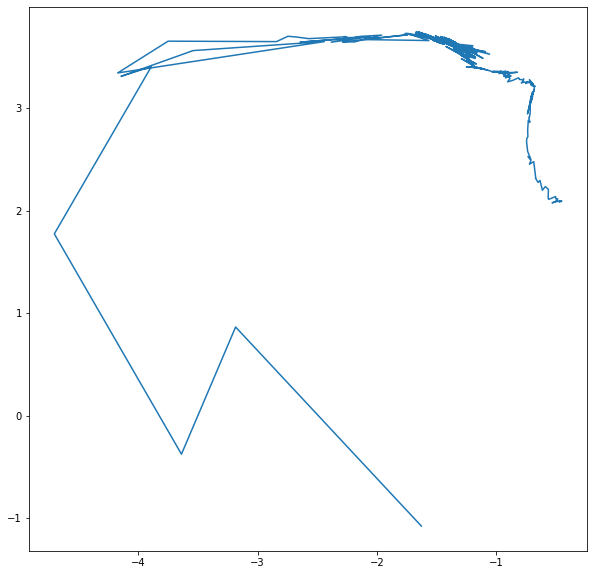

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.plot(gen_traj_np[:, 0], gen_traj_np[:, 1])
plt.show()

In [134]:
X = torch.hstack((torch.FloatTensor(time_traj[:-2]).unsqueeze(-1), torch.FloatTensor(actions), torch.FloatTensor(traj[:-1])))
X = X.to('cuda')

In [75]:
def ode_system(x, y):
    # x is assumed to be [x, y, theta, u, v]
    # y is assumed to be [x_next, y_next, theta_next]
    print('x shape: ', x.shape)
    print('y, ', y.shape)
    y1, y2, y3 = y[:, 0], y[:, 1], y[:, 2]
    dy1_x = dde.grad.jacobian(y, x, i=0, j=0)
    dy2_x = dde.grad.jacobian(y, x, i=1, j=0)
    dy3_x = dde.grad.jacobian(y, x, i=2, j=0)
    
    print('dy1_x  pre selection: ', dy1_x.shape)
    print('-----------------')


    dy1_x = dy1_x.squeeze(-1)
    dy2_x = dy2_x.squeeze(-1)
    dy3_x = dy3_x.squeeze(-1)
    
    print('dy1_x  post selection: ', dy1_x.shape)
    print('-----------------')

    print(f'dy1 - y1: {dy1_x.shape}, {y1.shape}')
    print(f'dy2 - y2: {dy2_x.shape}, {y2.shape}')
    print(f'dy3 - y3: {dy3_x.shape}, {y3.shape}')

    return [dy1_x - y1, dy2_x - y2, dy3_x - y3]

In [76]:
def boundary(x, on_initial):
    return dde.utils.isclose(x[0], 0)

In [78]:
ic1 = dde.icbc.IC(geomtime, lambda x: 0, boundary, component=0)
ic2 = dde.icbc.IC(geomtime, lambda x: 1, boundary, component=1)
ic3 = dde.icbc.IC(geomtime, lambda x: 0, boundary, component=2)
ic4 = dde.icbc.IC(geomtime, lambda x: 1, boundary, component=3)
ic5 = dde.icbc.IC(geomtime, lambda x: 0, boundary, component=4)


In [79]:
ic_list = [
    ic1
]

In [84]:
layer_size = [5] + [50] * 3 + [3]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

In [85]:
data = dde.data.PDE(geomtime, ode_system, [],  35, 0, solution=uniKin, num_test=100)

x_shape oriignial :  (35, 5)
x shape   (35, 3)
u shape   (35, 2)
x_shape oriignial :  (243, 5)
x shape   (243, 3)
u shape   (243, 2)


In [86]:
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

Compiling model...
'compile' took 0.000161 s



In [87]:
losshistory, train_state = model.train(iterations=20000)

Training model...

x shape:  torch.Size([35, 5])
y,  torch.Size([35, 3])
dy1_x  pre selection:  torch.Size([35, 1])
-----------------
dy1_x  post selection:  torch.Size([35])
-----------------
dy1 - y1: torch.Size([35]), torch.Size([35])
dy2 - y2: torch.Size([35]), torch.Size([35])
dy3 - y3: torch.Size([35]), torch.Size([35])
x shape:  torch.Size([243, 5])
y,  torch.Size([243, 3])
dy1_x  pre selection:  torch.Size([243, 1])
-----------------
dy1_x  post selection:  torch.Size([243])
-----------------
dy1 - y1: torch.Size([243]), torch.Size([243])
dy2 - y2: torch.Size([243]), torch.Size([243])
dy3 - y3: torch.Size([243]), torch.Size([243])


ValueError: operands could not be broadcast together with shapes (729,) (243,3) 